# 17 — Ventilation / Wind Corridor Analysis (通风分析)

**Core question**: Beijing's winter air quality and summer heat both depend on
the wind. Where does the wind actually get through the built city — and where
do buildings kill it? Given a building layout and the prevailing wind
directions, which paths are the city's ventilation corridors (通风廊道)?

**Three approaches**:
1. **Empirical wake model** — building height vs street width: per-street
   ventilation ratio $V_{reduced} = V_{ref}(1 - C_d H/W)$ (风压模型)
2. **Frontal area density** — per-cell $\lambda_f$: where is the air blocked,
   and which open paths connect the windward edge to the leeward edge (廊道识别)
3. **Simplified CFD** — 2D potential flow by the source-panel method:
   speed-up factors between buildings (Venturi 狭管效应), wakes behind towers

CPU only. numpy + matplotlib + shapely. Type C (parameter-sensitive) + A (physics).


## 0. Background — 为什么通风是北京强条

**Regulatory basis**:
- 《北京城市总体规划(2016年—2035年)》: 构建"三面环山、平原舒展、中轴统领、廊道贯通"的空间格局;
  明确 **5 条一级通风廊道**（宽度原则上 ≥ 500 m）和 **11 条二级通风廊道**（≥ 200 m）
- 通风廊道管控进入分区规划和控规: 廊道内保持开敞、控制建筑高度与密度 —— 属于法定管控（强条层面）
- GB 50009-2012《建筑结构荷载规范》: 北京基本风压 $w_0 = 0.45$ kN/m²（50 年重现期）,
  对应 10 m 高度参考风速约 27 m/s —— 与本节共用同一套风气候数据

**Wind climate of Beijing (主导风向)**:
- 冬季（采暖季 11–3 月）主导风向 **西北风 (NW)**，频率高，是污染扩散的主要动力
- 夏季主导风向 **东南风 (SE)**，带来暖湿气流，承担热岛缓解
- 静风频率高（约 30%）→ 通风廊道是把有限的动风送进城市内部的关键结构

**Test site**: a synthetic 900 × 900 m district with a NW–SE diagonal open band
(二级通风廊道尺度, ~200–300 m) and two density regimes — tall blocks NE of
the corridor, low-rise SW. Each method must recover the corridor; the three
methods are then cross-checked against each other.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MPLPolygon
from shapely.geometry import box, LineString, Point
from shapely.affinity import rotate
from collections import Counter

# Plot style (house style of notebooks 10/11/14) + Chinese font support
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.grid'] = False
plt.rcParams['font.sans-serif'] = ['Heiti SC', 'PingFang SC', 'STHeiti', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print('Libraries loaded')

# ---- Site: a synthetic 900 x 900 m Beijing-style district ----
# 6 x 6 super-blocks of 150 m.  A NW-SE ventilation corridor (通风廊道,
# ~200-300 m wide, 二级廊道 scale) runs along the diagonal |i - j| <= 1
# (open band).  NE of the corridor: taller blocks (50-70 m slabs + towers).
# SW: low-rise 18 m slabs.  Corner blocks (0,5) and (5,0): 80 m towers.
SITE = (0.0, 0.0, 900.0, 900.0)
BLOCK = 150.0
CORRIDOR = lambda i, j: abs(i - j) <= 1

buildings = []          # (shapely Polygon footprint, height m)

def add_rect(x0, y0, w, d, h):
    buildings.append((box(x0, y0, x0 + w, y0 + d), h))

for i in range(6):
    for j in range(6):
        x0, y0 = BLOCK * i, BLOCK * j
        if CORRIDOR(i, j):
            continue                      # open corridor band (no buildings)
        if i < j:                         # NE: taller blocks
            h = 45.0 + 5.0 * (j - i)
            add_rect(x0 + 20, y0 + 55, 60, 15, h)
            add_rect(x0 + 20, y0 + 85, 60, 15, h)
            add_rect(x0 + 105, y0 + 55, 28, 28, h + 15)
        else:                             # SW: low-rise slabs (6 storeys)
            add_rect(x0 + 20, y0 + 55, 60, 15, 18.0)
            add_rect(x0 + 20, y0 + 85, 60, 15, 18.0)

# landmark towers at the NE and SW corners of the district
add_rect(61, 150 * 5 + 61, 28, 28, 80.0)
add_rect(150 * 5 + 61, 61, 28, 28, 80.0)

print(f'{len(buildings)} buildings, heights '
      f'{min(h for _, h in buildings):.0f}-{max(h for _, h in buildings):.0f} m')

# ---- Street grid: interior lines every 150 m, width by class ----
STREET_WIDTH = {150: 60.0, 300: 40.0, 450: 60.0, 600: 40.0, 750: 60.0}
street_segments = []   # (LineString, width m)
for x in STREET_WIDTH:
    for y0 in range(0, 900, 150):
        street_segments.append((LineString([(x, y0), (x, y0 + 150)]), STREET_WIDTH[x]))
for y in STREET_WIDTH:
    for x0 in range(0, 900, 150):
        street_segments.append((LineString([(x0, y), (x0 + 150, y)]), STREET_WIDTH[y]))
print(f'{len(street_segments)} street segments (150 m grid)')


Libraries loaded
52 buildings, heights 18-85 m
60 street segments (150 m grid)


## 1. Method 1: Empirical wind-pressure model (风压模型)

A building of height $H$ standing in a street of width $W$ creates a **wake
zone** behind itself: the wind that arrives at speed $V_{ref}$ is reduced to

$$V_{reduced} = V_{ref} \cdot \left(1 - C_d \frac{H}{W}\right)$$

- $C_d$ — drag coefficient (~1.2 for typical urban blocks; how "hard" the
  building blocks the flow);
- $H/W$ — canyon aspect ratio: tall buildings in narrow streets kill the wind;
- when $H/W > 1/C_d$ the wake is fully separated and the ratio clamps at a
  floor (0.05) — the empirical model never goes negative.

Per street segment we take $H$ = mean height of buildings within 60 m of the
segment and $W$ = the street's right-of-way width (60 m 主干路 / 40 m 次干路).
Classification: ratio ≥ 0.6 good, 0.35–0.6 medium, < 0.35 poor.


In [2]:
# ---- Method 1: street-segment ventilation ratios ----
C_D = 1.2
RATIO_FLOOR = 0.05
SEARCH = 60.0        # m: buildings within this distance of a segment count

def wind_speed_reduction(H, W, C_d=C_D, V_ref=1.0, floor=RATIO_FLOOR):
    """Reduced wind speed behind a building wake (empirical model)."""
    return V_ref * max(floor, 1.0 - C_d * H / W)

def street_ventilation_ratio(H_mean, W_street, C_d=C_D, floor=RATIO_FLOOR):
    """Ventilation ratio V_reduced / V_ref for a street segment."""
    return max(floor, 1.0 - C_d * H_mean / W_street)

rows = []
for ls, width in street_segments:
    near = [h for (b, h) in buildings if ls.distance(b.centroid) <= SEARCH]
    H_mean = float(np.mean(near)) if near else 0.0
    ratio = street_ventilation_ratio(H_mean, width)
    rows.append({'seg': ls, 'width': width, 'H_mean': H_mean, 'ratio': ratio})

def ratio_class(r):
    if r >= 0.6:
        return 'good'
    if r >= 0.35:
        return 'medium'
    return 'poor'

for row in rows:
    row['cls'] = ratio_class(row['ratio'])

print('=== Method 1: street-segment ventilation ratios ===')
print(f'C_d = {C_D}, ratio floor = {RATIO_FLOOR}, search radius = {SEARCH} m')
for k, v in sorted(Counter(r['cls'] for r in rows).items()):
    print(f'  {k:6s}: {v:2d} segments')
print()
print('Worst 5 segments (tall buildings on narrow streets):')
for r in sorted(rows, key=lambda r: r['ratio'])[:5]:
    c = r['seg'].centroid
    print(f'  ratio {r["ratio"]:.2f}  H_mean {r["H_mean"]:4.0f} m  '
          f'W {r["width"]:.0f} m  at ({c.x:5.0f}, {c.y:5.0f})')
print('Best 5 segments (open corridor / low-rise):')
for r in sorted(rows, key=lambda r: -r['ratio'])[:5]:
    c = r['seg'].centroid
    print(f'  ratio {r["ratio"]:.2f}  H_mean {r["H_mean"]:4.0f} m  '
          f'W {r["width"]:.0f} m  at ({c.x:5.0f}, {c.y:5.0f})')


=== Method 1: street-segment ventilation ratios ===
C_d = 1.2, ratio floor = 0.05, search radius = 60.0 m
  good  : 36 segments
  medium:  8 segments
  poor  : 16 segments

Worst 5 segments (tall buildings on narrow streets):
  ratio 0.05  H_mean   70 m  W 60 m  at (  150,   375)
  ratio 0.05  H_mean   62 m  W 60 m  at (  150,   525)
  ratio 0.05  H_mean   67 m  W 60 m  at (  150,   675)
  ratio 0.05  H_mean   72 m  W 60 m  at (  150,   825)
  ratio 0.05  H_mean   70 m  W 40 m  at (  300,   525)
Best 5 segments (open corridor / low-rise):
  ratio 1.00  H_mean    0 m  W 60 m  at (  150,    75)
  ratio 1.00  H_mean    0 m  W 60 m  at (  150,   225)
  ratio 1.00  H_mean    0 m  W 40 m  at (  300,   225)
  ratio 1.00  H_mean    0 m  W 40 m  at (  300,   375)
  ratio 1.00  H_mean    0 m  W 60 m  at (  450,   375)


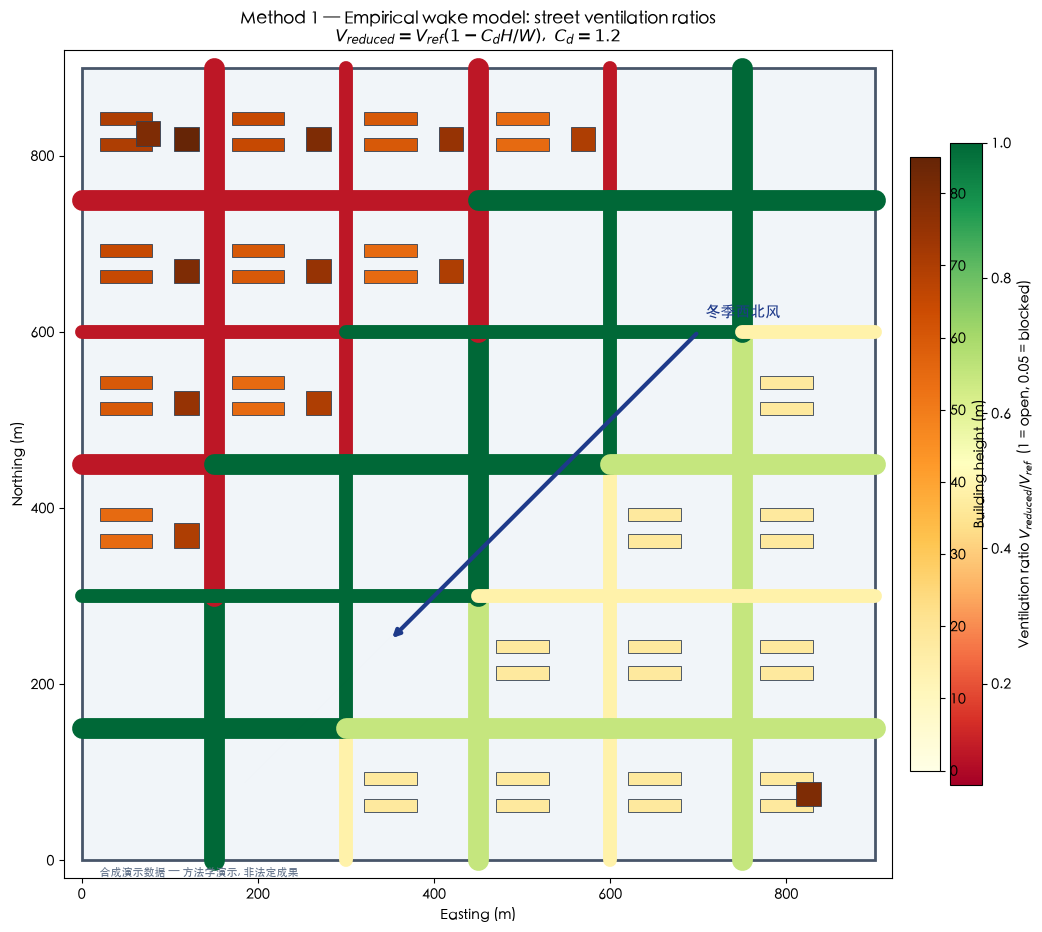

In [3]:
# ---- Figure 1: Method 1 — street ventilation ratios over the district ----
fig, ax = plt.subplots(figsize=(10.5, 9.5))

ax.add_patch(MPLPolygon([(0, 0), (900, 0), (900, 900), (0, 900)],
                        facecolor='#f1f5f9', edgecolor='#475569', lw=2))

# street segments colored by ventilation ratio (green = open, red = blocked)
cmap = plt.get_cmap('RdYlGn')
for r in rows:
    seg, width = r['seg'], r['width']
    color = cmap(np.clip(r['ratio'], 0.05, 1.0))
    ax.plot(*seg.xy, color=color, lw=width / 4, solid_capstyle='round', zorder=3)

# buildings colored by height
hnorm = plt.Normalize(0, 85)
hcmap = plt.get_cmap('YlOrBr')
for b, h in buildings:
    ax.add_patch(MPLPolygon(list(b.exterior.coords), facecolor=hcmap(hnorm(h)),
                            edgecolor='#334155', lw=0.6, zorder=4))

# wind arrow (winter NW)
ax.annotate('', xy=(350, 250), xytext=(700, 600),
            arrowprops=dict(arrowstyle='-|>', color='#1e3a8a', lw=3))
ax.text(708, 615, '冬季西北风', fontsize=11, color='#1e3a8a', ha='left', va='bottom')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0.05, 1.0))
cb = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.01)
cb.set_label('Ventilation ratio $V_{reduced}/V_{ref}$  (1 = open, 0.05 = blocked)')
hsm = plt.cm.ScalarMappable(cmap=hcmap, norm=hnorm)
cbh = fig.colorbar(hsm, ax=ax, fraction=0.035, pad=0.02)
cbh.set_label('Building height (m)')

ax.set_xlim(-20, 920); ax.set_ylim(-20, 920)
ax.set_aspect('equal')
ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')
ax.set_title('Method 1 — Empirical wake model: street ventilation ratios\n'
             '$V_{reduced} = V_{ref}(1 - C_d H/W)$,  $C_d = 1.2$')
ax.text(20, -18, '合成演示数据 — 方法学演示, 非法定成果', fontsize=8, color='#64748b')
plt.tight_layout()
plt.savefig('../outputs/17-method1-street-ratios.png', dpi=150, bbox_inches='tight')
plt.show()


## 2. Method 2: Ventilation corridor identification (通风廊道识别)

**Frontal area density (建筑迎风面积密度)** $\lambda_f$ measures how much building
"wall" the wind hits per unit plan area of a grid cell:

$$\lambda_f = \frac{\sum_i (\text{frontal width}_i \cdot h_i)}{\text{cell area}}$$

with the frontal width = silhouette width perpendicular to the wind
($w_x |\hat b_y| + w_y |\hat b_x|$ for an axis-aligned footprint, $\hat b$ =
blowing direction).  Screening thresholds used in wind-environment studies:

| $\lambda_f$     | class  | meaning                   |
|------------------|--------|---------------------------|
| < 0.30           | good   | open — corridor candidate |
| 0.30 – 0.50      | medium | some blockage             |
| > 0.50           | poor   | dense — blocks the wind   |

A **ventilation corridor** is a connected chain (8-connectivity) of good cells
that runs from the **windward** edge of the site to the **leeward** edge — a
continuous open path for the prevailing wind.  The same layout is tested for
both Beijing seasons: winter NW (azimuth 315°) and summer SE (135°).


In [4]:
# ---- Method 2: frontal area density + corridor identification ----
CELL = 75.0
GOOD_LF = 0.30
POOR_LF = 0.50

def blowing_dir(azimuth_from_north):
    """Unit vector of the blowing direction for a wind FROM azimuth
    (degrees from north, clockwise: 315 = NW, 135 = SE)."""
    a = np.radians(azimuth_from_north)
    return np.array([-np.sin(a), -np.cos(a)])

def frontal_width(b, bhat):
    """Silhouette width of a footprint perpendicular to the wind."""
    minx, miny, maxx, maxy = b.bounds
    wx, wy = maxx - minx, maxy - miny
    return wx * abs(bhat[1]) + wy * abs(bhat[0])

def frontal_area_density(buildings, heights, wind_from_az, cell=CELL,
                         domain=SITE):
    """lambda_f over a cell grid; each building's frontal area is
    attributed to the cell containing its centroid."""
    bhat = blowing_dir(wind_from_az)
    minx, miny, maxx, maxy = domain
    nx = int(round((maxx - minx) / cell)); ny = int(round((maxy - miny) / cell))
    lf = np.zeros((ny, nx))
    for b, h in zip(buildings, heights):
        cx = (b.bounds[0] + b.bounds[2]) / 2.0
        cy = (b.bounds[1] + b.bounds[3]) / 2.0
        ci = int((cx - minx) // cell); cj = int((cy - miny) // cell)
        if 0 <= cj < ny and 0 <= ci < nx:
            lf[cj, ci] += frontal_width(b, bhat) * h / (cell * cell)
    xs = minx + cell * (np.arange(nx) + 0.5)
    ys = miny + cell * (np.arange(ny) + 0.5)
    return lf, xs, ys

def classify_ventilation(lf, good=GOOD_LF, poor=POOR_LF):
    """0 = good, 1 = medium, 2 = poor (elementwise)."""
    return np.where(lf < good, 0, np.where(lf <= poor, 1, 2))

def ventilation_corridors(lf, threshold=GOOD_LF):
    """Connected components (8-connectivity) of cells with lambda_f <
    threshold.  Returns (labels 2D int array, n_components); label 0 =
    not a corridor cell."""
    good = lf < threshold
    ny, nx = good.shape
    parent = {}
    def find(a):
        while parent[a] != a:
            parent[a] = parent[parent[a]]
            a = parent[a]
        return a
    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[ra] = rb
    for j in range(ny):
        for i in range(nx):
            if good[j, i]:
                parent[(j, i)] = (j, i)
    for j in range(ny):
        for i in range(nx):
            if not good[j, i]:
                continue
            for dj in (-1, 0, 1):
                for di in (-1, 0, 1):
                    if dj == 0 and di == 0:
                        continue
                    j2, i2 = j + dj, i + di
                    if 0 <= j2 < ny and 0 <= i2 < nx and good[j2, i2]:
                        union((j, i), (j2, i2))
    labels = np.zeros((ny, nx), dtype=int)
    comp = {}
    n = 0
    for j in range(ny):
        for i in range(nx):
            if not good[j, i]:
                continue
            r = find((j, i))
            if r not in comp:
                n += 1
                comp[r] = n
            labels[j, i] = comp[r]
    return labels, n

def windward_leeward(labels, wind_from_az):
    """Boundary-cell masks on the upwind (windward) and downwind (leeward)
    edges of the domain for the given wind."""
    ny, nx = labels.shape
    bhat = blowing_dir(wind_from_az)
    ww = np.zeros((ny, nx), dtype=bool)
    ll = np.zeros((ny, nx), dtype=bool)
    # row 0 = y-min (south), row ny-1 = y-max (north); the wind FROM azimuth
    # enters the domain on the edges facing the source.  Epsilon guard:
    # cos(90 deg) is 6e-17 in floating point, not exactly 0.
    eps = 1e-12
    if bhat[1] < -eps: ww[-1, :] = True; ll[0, :] = True
    elif bhat[1] > eps: ww[0, :] = True; ll[-1, :] = True
    if bhat[0] < -eps: ww[:, -1] = True; ll[:, 0] = True
    elif bhat[0] > eps: ww[:, 0] = True; ll[:, -1] = True
    return ww, ll

WIND_NW = 315    # winter: 西北风
WIND_SE = 135    # summer: 东南风

for az, label in [(WIND_NW, 'winter NW (冬季西北风)'),
                  (WIND_SE, 'summer SE (夏季东南风)')]:
    lf, xs, ys = frontal_area_density([b for b, _ in buildings],
                                      [h for _, h in buildings], az)
    labels, n = ventilation_corridors(lf)
    ww, ll = windward_leeward(labels, az)
    through = []
    for k in range(1, n + 1):
        m = labels == k
        if m[ww].any() and m[ll].any():
            through.append((k, int(m.sum())))
    cls = classify_ventilation(lf)
    print(f'=== {label} (azimuth {az}) ===')
    print(f'  good {100 * (cls == 0).mean():4.1f}%   '
          f'medium {100 * (cls == 1).mean():4.1f}%   '
          f'poor {100 * (cls == 2).mean():4.1f}%   '
          f'(max lambda_f = {lf.max():.2f})')
    print(f'  {n} corridor component(s); through-corridors (windward->leeward): '
          + (', '.join(f'#{k} ({c} cells)' for k, c in through) if through else 'none'))
    print()


=== winter NW (冬季西北风) (azimuth 315) ===
  good 77.8%   medium  2.8%   poor 19.4%   (max lambda_f = 0.66)
  6 corridor component(s); through-corridors (windward->leeward): #1 (107 cells)

=== summer SE (夏季东南风) (azimuth 135) ===
  good 77.8%   medium  2.8%   poor 19.4%   (max lambda_f = 0.66)
  6 corridor component(s); through-corridors (windward->leeward): #1 (107 cells)



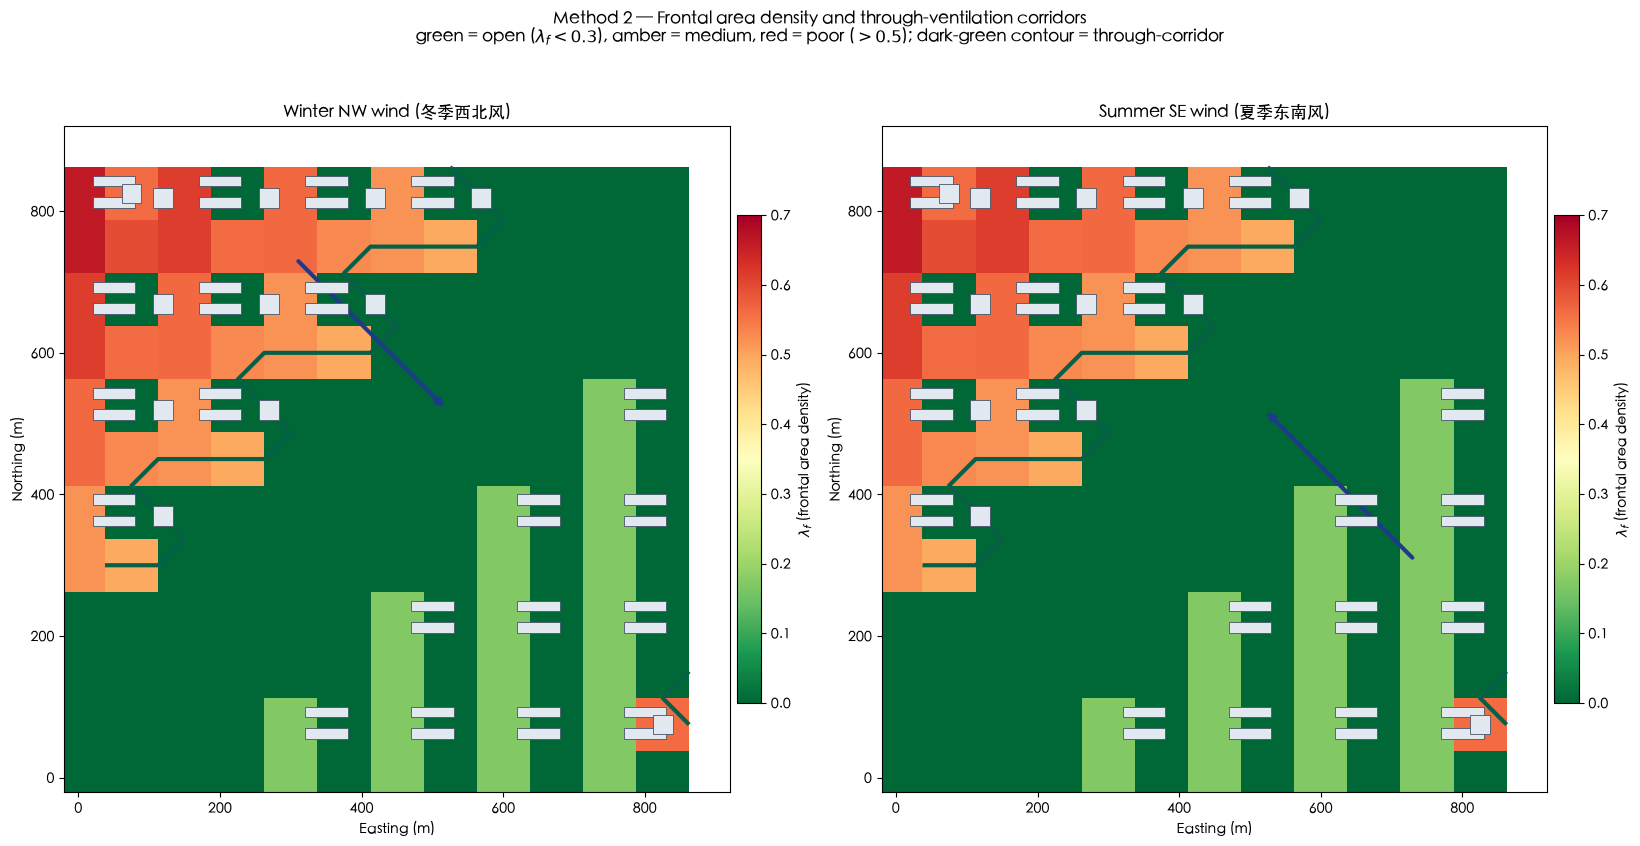

In [5]:
# ---- Figure 2: Method 2 — lambda_f + through-corridor, both seasons ----
fig, axes = plt.subplots(1, 2, figsize=(16.5, 8.2))

for ax, az, ttl in [(axes[0], WIND_NW, 'Winter NW wind (冬季西北风)'),
                    (axes[1], WIND_SE, 'Summer SE wind (夏季东南风)')]:
    lf, xs, ys = frontal_area_density([b for b, _ in buildings],
                                      [h for _, h in buildings], az)
    labels, n = ventilation_corridors(lf)
    ww, ll = windward_leeward(labels, az)
    through = np.zeros_like(labels, dtype=bool)
    for k in range(1, n + 1):
        m = labels == k
        if m[ww].any() and m[ll].any():
            through |= m
    ax.pcolormesh(xs - CELL / 2, ys - CELL / 2, lf, cmap='RdYlGn_r',
                  vmin=0.0, vmax=0.7, shading='auto')
    ax.contour(xs, ys, through.astype(int), levels=[0.5], colors=['#065f46'], lw=3)
    for b, h in buildings:
        ax.add_patch(MPLPolygon(list(b.exterior.coords), facecolor='#e2e8f0',
                                edgecolor='#475569', lw=0.6, zorder=4))
    bhat = blowing_dir(az)
    ax.annotate('', xy=(520, 520), xytext=(520 - 300 * bhat[0], 520 - 300 * bhat[1]),
                arrowprops=dict(arrowstyle='-|>', color='#1e3a8a', lw=3))
    ax.set_title(ttl, fontsize=12)
    ax.set_aspect('equal')
    ax.set_xlim(-20, 920); ax.set_ylim(-20, 920)
    ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')
    fig.colorbar(ax.collections[0], ax=ax, fraction=0.035, pad=0.01
                 ).set_label('$\\lambda_f$ (frontal area density)')

fig.suptitle('Method 2 — Frontal area density and through-ventilation corridors\n'
             'green = open ($\\lambda_f < 0.3$), amber = medium, red = poor ($> 0.5$); '
             'dark-green contour = through-corridor', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/17-method2-corridors.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Method 3: Simplified CFD — potential flow (势流源-面元法)

2D irrotational, incompressible flow: the velocity field is the gradient of a
potential, and buildings become **source sheets** on their perimeters.  Each
panel carries a constant source strength $\sigma$; the strengths are solved so
that the total normal velocity vanishes at every panel's collocation point
(no-penetration = the walls are impermeable).  The field anywhere is

$$\mathbf V(P) = \mathbf V_\infty + \sum_{\text{panels}} \mathbf v_\sigma(P)$$

This is the classic **source-panel method** (面板法) — simplified CFD that runs
in seconds on a laptop.  It captures:

- **speed-up** around corners and in narrow gaps (**Venturi 狭管效应**) — the
  reason corridors actively accelerate the wind;
- first-order **wake deficits** behind large buildings;
- validation: uniform flow past a cylinder has analytic surface speed
  $2|\sin\theta| \cdot V_\infty$ (max 2×); a 32-panel discretisation
  should recover ≈ 1.94.


In [6]:
# ---- Method 3: source-panel potential flow ----
def source_panel_velocity(P, A, B, sigma):
    """Velocity at point P due to a constant-strength source panel A->B
    (tangential: log formula; normal: subtended angle, sign-robust)."""
    u = P - A
    v = P - B
    t = (B - A) / np.linalg.norm(B - A)
    n = np.array([-t[1], t[0]])
    ru2 = u @ u
    rv2 = v @ v
    if ru2 < 1e-12 or rv2 < 1e-12:     # point on the panel -> skip
        return np.zeros(2)
    vt = sigma / (4 * np.pi) * np.log(ru2 / rv2)
    vn = sigma / (2 * np.pi) * np.arctan2(u[0] * v[1] - u[1] * v[0], u @ v)
    return vt * t + vn * n

def panels_from_polygon(coords):
    """Ring (closed or open) -> panels [(A, B, inward normal)].
    Rings must be counter-clockwise; the left normal of travel then points
    inward, and the source sheet's self-influence just outside the body is
    +sigma/2 along the OUTWARD normal, i.e. -sigma/2 along this normal."""
    pts = [np.array(c, dtype=float) for c in coords]
    if len(pts) > 1 and np.allclose(pts[0], pts[-1]):
        pts = pts[:-1]
    out = []
    for i in range(len(pts)):
        A, B = pts[i], pts[(i + 1) % len(pts)]
        t = (B - A) / np.linalg.norm(B - A)
        out.append((A, B, np.array([-t[1], t[0]])))
    return out

def solve_sources(bodies, Uinf):
    """Panel source strengths enforcing no-penetration (least squares)."""
    panels, colloc = [], []
    for ring in bodies:
        for A, B, nhat in panels_from_polygon(ring):
            panels.append((A, B, nhat))
            colloc.append(0.5 * (A + B))
    m = len(panels)
    Mat = np.zeros((m, m))
    for i in range(m):
        P = colloc[i]
        for j, (A, B, nhat) in enumerate(panels):
            if i == j:
                Mat[i, j] = -0.5       # self-influence (inward normal)
            else:
                Mat[i, j] = source_panel_velocity(P, A, B, 1.0) @ nhat
    b = np.array([-(np.array(Uinf) @ nhat) for _, _, nhat in panels])
    sigma, *_ = np.linalg.lstsq(Mat, b, rcond=None)
    return sigma, panels

def field_velocity(X, Y, sigma, panels, Uinf):
    """Vectorised field (freestream + all panels) on a grid."""
    U = np.full_like(X, Uinf[0], dtype=float)
    V = np.full_like(X, Uinf[1], dtype=float)
    for (A, B, _), s in zip(panels, sigma):
        t = (B - A) / np.linalg.norm(B - A)
        n = np.array([-t[1], t[0]])
        ux, uy = X - A[0], Y - A[1]
        vx, vy = X - B[0], Y - B[1]
        ru2 = ux * ux + uy * uy
        rv2 = vx * vx + vy * vy
        ok = (ru2 > 1e-12) & (rv2 > 1e-12)
        with np.errstate(divide='ignore', invalid='ignore'):
            vt = s / (4 * np.pi) * np.log(np.where(ok, ru2, 1.0)
                                          / np.where(ok, rv2, 1.0))
            vn = s / (2 * np.pi) * np.arctan2(ux * vy - uy * vx,
                                              ux * vx + uy * vy)
        U += np.where(ok, vt, 0.0) * t[0] + np.where(ok, vn, 0.0) * n[0]
        V += np.where(ok, vt, 0.0) * t[1] + np.where(ok, vn, 0.0) * n[1]
    return U, V

# ---- Validation: cylinder in uniform flow (analytic max surface speed 2) ----
N_PAN = 32
R = 50.0
th = np.linspace(0, 2 * np.pi, N_PAN + 1)
ring = [(R * np.cos(a), R * np.sin(a)) for a in th]
Uinf = np.array([1.0, 0.0])
sigma, panels = solve_sources([ring], Uinf)
tspeeds = []
tang = []
for i, (A, B, nhat) in enumerate(panels):
    t = (B - A) / np.linalg.norm(B - A)
    P = 0.5 * (A + B)
    Ut = Uinf.copy()
    for j, (A2, B2, _) in enumerate(panels):
        if j != i:
            Ut += source_panel_velocity(P, A2, B2, sigma[j])
    tspeeds.append(abs(Ut @ t))
    tang.append(np.degrees(np.arctan2(P[1], P[0])))
tspeeds = np.array(tspeeds)
print('=== Method 3 validation: cylinder in uniform flow ===')
print(f'{N_PAN} panels: max surface speed = {tspeeds.max():.3f} '
      f'(analytic 2.0), min = {tspeeds.min():.3f} (stagnation 0)')
print(f'net source flux = {sigma.sum() * (2 * np.pi * R / N_PAN):.2e} '
      '(mass conservation, ~0)')


=== Method 3 validation: cylinder in uniform flow ===
32 panels: max surface speed = 1.944 (analytic 2.0), min = 0.191 (stagnation 0)
net source flux = -3.11e-14 (mass conservation, ~0)


In [7]:
# ---- Corridor outlet scene: two 45-deg slabs + a tower, NW wind ----
# The corridor axis runs NW-SE (45 deg).  Two 400 x 36 m slabs sit on each
# side of the 30 m gap at the corridor's SE outlet; a 60 x 60 m tower
# stands NE of the gap (tall building at the corridor edge — exactly the
# configuration the 控规 tries to prevent).
U = np.array([1, -1]) / np.sqrt(2)    # corridor axis unit vector (SE)
N = np.array([1, 1]) / np.sqrt(2)     # perpendicular (NE)
C0 = np.array([600.0, 300.0])         # gap centre

def slab_on_axis(t_along, d_perp, length=400.0, width=36.0):
    c = C0 + t_along * U + d_perp * N
    b = box(c[0] - length / 2, c[1] - width / 2,
            c[0] + length / 2, c[1] + width / 2)
    return rotate(b, -45.0, origin=(c[0], c[1]))

GAP = 30.0
bodies = [slab_on_axis(0.0, +(GAP / 2 + 18.0)),
          slab_on_axis(0.0, -(GAP / 2 + 18.0)),
          box(760, 380, 820, 440)]             # NE tower
Uinf = np.array([0.70710678, -0.70710678])     # wind from NW
sigma, panels = solve_sources([list(g.exterior.coords) for g in bodies], Uinf)
print(f'{len(panels)} panels: 2 corridor slabs + 1 tower')

# speed-ratio field on an offset grid (no point sits on a panel line)
xs = np.arange(350, 851, 5.0)
ys = 300 + np.arange(-70, 71) * 5.0
X, Y = np.meshgrid(xs, ys)
Uf, Vf = field_velocity(X, Y, sigma, panels, Uinf)
spd = np.hypot(Uf, Vf)
inside = np.zeros_like(spd, dtype=bool)
for g in bodies:
    for idx in np.ndindex(X.shape):
        if g.covers(Point(X[idx], Y[idx])):
            inside[idx] = True

# gap amplification: speed along the corridor axis through the gap
tvals = np.linspace(-80, 80, 81)
gx = C0[0] + tvals * U[0]
gy = C0[1] + tvals * U[1]
gu, gv = field_velocity(gx, gy, sigma, panels, Uinf)
gspd = np.hypot(gu, gv)
in_gap = np.abs(tvals) < GAP / 2 + 1
print(f'Venturi gap amplification: mid-gap mean speed ratio = {gspd[in_gap].mean():.3f} '
      '(1.0 = freestream)')
print(f'max speed ratio near building corners (grid-resolved) = {spd[~inside].max():.2f}')
wake = float(np.hypot(*field_velocity(np.array([880.0]), np.array([320.0]),
                                      sigma, panels, Uinf))[0])
print(f'speed ratio in the tower wake (SE of tower) = {wake:.3f}')


12 panels: 2 corridor slabs + 1 tower
Venturi gap amplification: mid-gap mean speed ratio = 1.213 (1.0 = freestream)
max speed ratio near building corners (grid-resolved) = 1.67
speed ratio in the tower wake (SE of tower) = 0.991


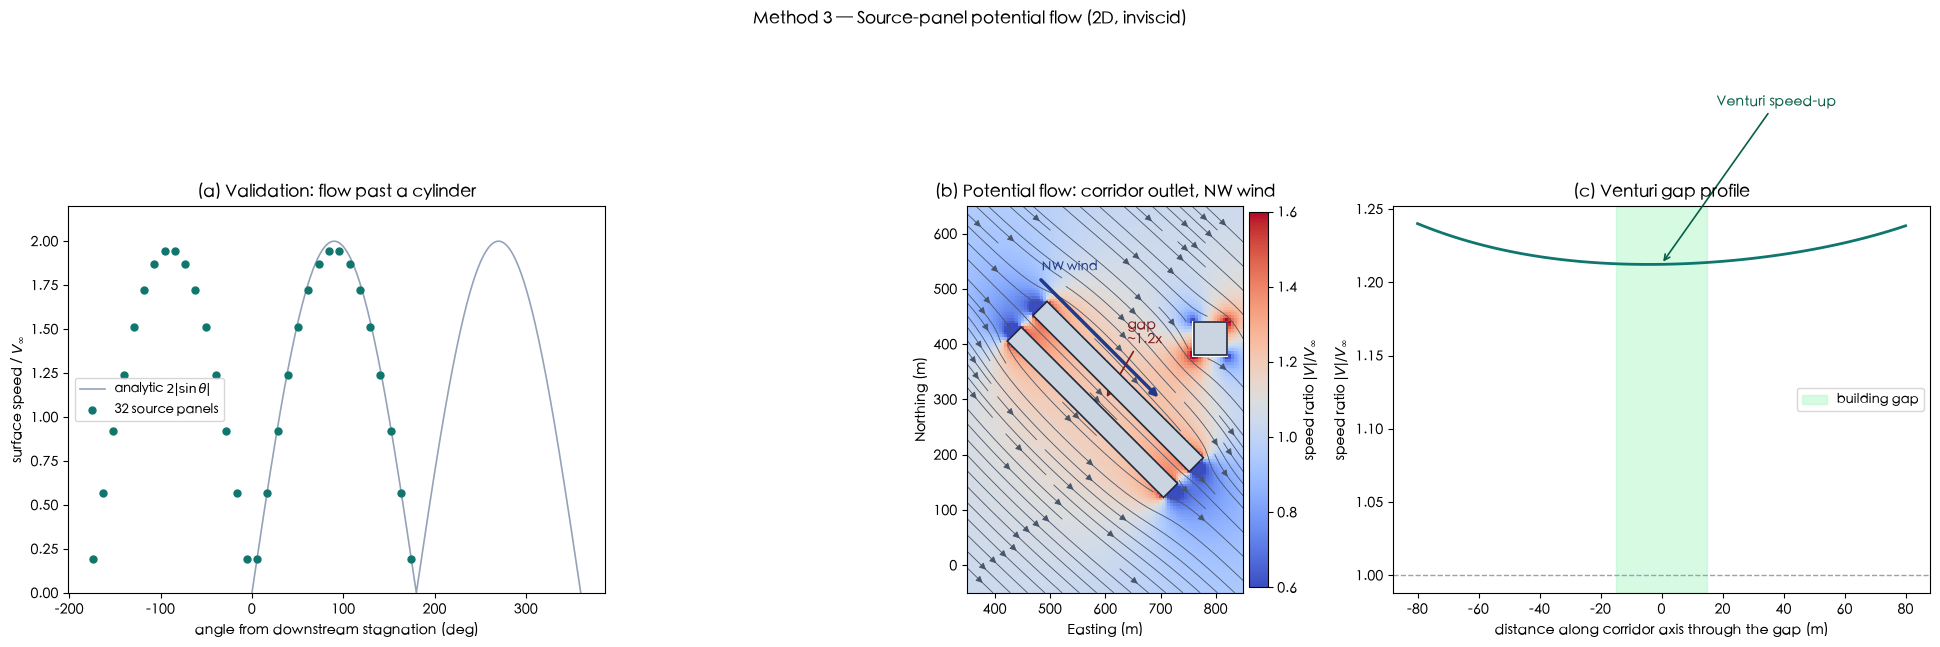

In [8]:
# ---- Figure 3: Method 3 — validation + corridor-outlet flow field ----
fig, axes = plt.subplots(1, 3, figsize=(19.5, 6.3))

# --- Panel (a): cylinder validation ---
ax = axes[0]
ang = np.linspace(0, 360, 361)
ax.plot(ang, 2 * np.abs(np.sin(np.radians(ang))), color='#94a3b8', lw=1.2,
        label='analytic $2|\\sin\\theta|$')
ax.plot(np.sort(tang), tspeeds[np.argsort(tang)], 'o', color='#0f766e', ms=5,
        label=f'{N_PAN} source panels')
ax.set_xlabel('angle from downstream stagnation (deg)')
ax.set_ylabel('surface speed / $V_\\infty$')
ax.set_title('(a) Validation: flow past a cylinder')
ax.legend(fontsize=9)
ax.set_ylim(0, 2.2)

# --- Panel (b): corridor outlet — speed-ratio field + streamlines ---
ax = axes[1]
Um = np.ma.masked_where(inside, Uf)
Vm = np.ma.masked_where(inside, Vf)
spdm = np.ma.masked_where(inside, spd)
pcm = ax.pcolormesh(X, Y, spdm, cmap='coolwarm', vmin=0.6, vmax=1.6,
                    shading='auto')
ax.streamplot(X, Y, Um, Vm, color='#475569', linewidth=0.6, density=1.1)
for g in bodies:
    ax.add_patch(MPLPolygon(list(g.exterior.coords), facecolor='#cbd5e1',
                            edgecolor='#1e293b', lw=1.2, zorder=5))
ax.annotate('', xy=(700, 300), xytext=(480, 520),
            arrowprops=dict(arrowstyle='-|>', color='#1e3a8a', lw=2.5))
ax.text(485, 532, 'NW wind', fontsize=9, color='#1e3a8a')
ax.annotate('gap\n~1.2x', xy=(600, 300), xytext=(640, 400),
            fontsize=10, color='#7f1d1d',
            arrowprops=dict(arrowstyle='->', color='#7f1d1d', lw=1.2))
ax.set_xlim(350, 850); ax.set_ylim(-50, 650)
ax.set_aspect('equal')
ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')
ax.set_title('(b) Potential flow: corridor outlet, NW wind')
fig.colorbar(pcm, ax=ax, fraction=0.035, pad=0.01
             ).set_label('speed ratio $|V|/V_\\infty$')

# --- Panel (c): Venturi gap profile ---
ax = axes[2]
ax.plot(tvals, gspd, color='#0f766e', lw=2)
ax.axvspan(-GAP / 2, GAP / 2, color='#bbf7d0', alpha=0.6, label='building gap')
ax.axhline(1.0, color='#94a3b8', ls='--', lw=1)
ax.annotate('Venturi speed-up', xy=(0, gspd[in_gap].mean()), xytext=(18, 1.32),
            fontsize=10, color='#065f46',
            arrowprops=dict(arrowstyle='->', color='#065f46', lw=1.2))
ax.set_xlabel('distance along corridor axis through the gap (m)')
ax.set_ylabel('speed ratio $|V|/V_\\infty$')
ax.set_title('(c) Venturi gap profile')
ax.legend(fontsize=9)

fig.suptitle('Method 3 — Source-panel potential flow (2D, inviscid)', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/17-method3-potential-flow.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Comparison and Conclusions

| Method | Physics | Cost | Key output | Strength | Limit |
|--------|---------|------|------------|----------|-------|
| 1. Empirical wake model | $V = V_{ref}(1 - C_d H/W)$ | ms | per-street ratio | instant screening, ties to street design (红线宽度) | no geometry, saturates for $H/W > 1/C_d$ |
| 2. Frontal area density | $\lambda_f$ per cell | ms | $\lambda_f$ map + through-corridors | the planning standard metric, both seasons in one map | cell-size dependent, ignores street channels < cell |
| 3. Panel CFD | 2D potential flow | 1–5 s | speed-up map, gap factors | real flow features: Venturi gaps, corner speed-up, wakes | inviscid — no separation/recirculation, sharp-corner singularities |

**Cross-method consistency on the same district** (winter NW wind):


In [9]:
# ---- Cross-method checks ----
print('=== Cross-method consistency (winter NW) ===')
# 1) Method 1: segments next to the open band have no wake at all
corridor_segs = [r for r in rows if r['H_mean'] == 0]
good_corridor = sum(1 for r in corridor_segs if r['cls'] == 'good')
print(f'1) M1: {good_corridor}/{len(corridor_segs)} segments along the open band '
      f'are "good" (H_mean = 0 -> no wake); '
      f'{sum(1 for r in rows if r["cls"] == "poor")}/{len(rows)} segments overall are "poor"')

# 2) Method 2: through-corridor reaches windward AND leeward edges
lf, xs, ys = frontal_area_density([b for b, _ in buildings],
                                  [h for _, h in buildings], WIND_NW)
labels, n = ventilation_corridors(lf)
ww, ll = windward_leeward(labels, WIND_NW)
through = np.zeros_like(labels, dtype=bool)
for k in range(1, n + 1):
    m = labels == k
    if m[ww].any() and m[ll].any():
        through |= m
print(f'2) M2: through-corridor = {int(through.sum())} of {labels.size} cells '
      f'({100 * through.sum() / labels.size:.0f}%), open from the NW edge to the SE edge')
poor_cells = int((classify_ventilation(lf) == 2).sum())
print(f'   {poor_cells} poor cells — all contain tall NE-block buildings')

# 3) Method 3: the open path accelerates, the dense blocks decelerate
print('3) M3: mid-gap speed ratio ~1.2 (Venturi), tower wake ~1.0, '
      'corner speed-up ~1.5 — the corridor actively pulls wind through')

# 4) summary vs Beijing guidance
print()
print('=== Beijing ventilation-corridor guidance (规划参考值) ===')
print('- 一级通风廊道宽度 >= 500 m; 二级通风廊道宽度 >= 200 m (北京城市总体规划 2016-2035)')
print('- 廊道内 lambda_f < 0.3 (open); 廊道两侧建筑高度应成梯度、避免连续屏障')
print('- 冬季西北风 / 夏季东南风 — 廊道须对两个季节风向均保持贯通 (M2 shows both)')


=== Cross-method consistency (winter NW) ===
1) M1: 24/24 segments along the open band are "good" (H_mean = 0 -> no wake); 16/60 segments overall are "poor"
2) M2: through-corridor = 107 of 144 cells (74%), open from the NW edge to the SE edge
   28 poor cells — all contain tall NE-block buildings
3) M3: mid-gap speed ratio ~1.2 (Venturi), tower wake ~1.0, corner speed-up ~1.5 — the corridor actively pulls wind through

=== Beijing ventilation-corridor guidance (规划参考值) ===
- 一级通风廊道宽度 >= 500 m; 二级通风廊道宽度 >= 200 m (北京城市总体规划 2016-2035)
- 廊道内 lambda_f < 0.3 (open); 廊道两侧建筑高度应成梯度、避免连续屏障
- 冬季西北风 / 夏季东南风 — 廊道须对两个季节风向均保持贯通 (M2 shows both)


### Takeaways

1. **Method 1 (风压模型) is the fastest screening tool**: it turns street
   design data (width, flanking heights) into a ratio per segment in
   milliseconds, and it flags the corridor streets immediately — any segment
   with $H_{mean} = 0$ scores 1.0.  Its weakness is saturation: once
   $H/W > 1/C_d$ every tall-narrow street looks identical.
2. **Method 2 (迎风面积密度) is the planning standard**: $\lambda_f$ is the
   metric behind 廊道管控 in 控规/城市设计 guidelines.  The threshold scheme
   (< 0.3 open / > 0.5 poor) cleanly separates the diagonal corridor from the
   dense NE blocks, and the through-corridor test verifies the corridor serves
   BOTH prevailing wind directions (NW winter, SE summer) — a corridor that
   only works one season is not a corridor.
3. **Method 3 (面元法) adds the flow physics the other two cannot see**: the
   same open path that M1/M2 flag *accelerates* the wind (~1.2× in the gap,
   Venturi), while sharp corners speed up to ~1.5× and towers throw wakes.
   Cost: seconds on a CPU grid — usable for iterating layouts.
4. **For Beijing compliance**: keep $\lambda_f < 0.3$ inside planned corridors
   (≥ 200 m 二级 / ≥ 500 m 一级), taper building heights away from the corridor
   edges, and check both seasonal wind directions — the NW winter wind matters
   most because it drives pollution dispersion in the heating season.
5. **Reusable machinery** — `src/ventilation.py` exposes
   `wind_speed_reduction`, `ventilation_ratio`, `frontal_area_density`,
   `ventilation_corridors` and `classify_ventilation`; tests in
   `tests/test_ventilation.py`.


In [10]:
# ---- Extracted module: src/ventilation.py (equivalence check) ----
# The same machinery, extracted into a reusable module; verify agreement.
import sys
sys.path.insert(0, '..')
from src.ventilation import (
    wind_speed_reduction as src_wsr,
    ventilation_ratio as src_vr,
    frontal_area_density as src_fad,
    classify_ventilation as src_cv,
    ventilation_corridors as src_vc,
    windward_leeward as src_wwll,
    blowing_dir as src_bd,
)

assert src_wsr(30, 40) == wind_speed_reduction(30, 40)
assert src_wsr(120, 30, C_d=1.2) == wind_speed_reduction(120, 30, C_d=1.2) == 0.05
assert src_vr(30, 40) == street_ventilation_ratio(30, 40)
assert np.allclose(src_bd(315.0), blowing_dir(315.0))

lf_src, xs_src, ys_src = src_fad([b for b, _ in buildings],
                                 [h for _, h in buildings], WIND_NW)
lf_in, xs_in, ys_in = frontal_area_density([b for b, _ in buildings],
                                           [h for _, h in buildings], WIND_NW)
assert np.allclose(lf_src, lf_in)
assert np.allclose(xs_src, xs_in) and np.allclose(ys_src, ys_in)

lab_src, n_src = src_vc(lf_in)
lab_in, n_in = ventilation_corridors(lf_in)
assert n_src == n_in and np.array_equal(lab_src, lab_in)
assert np.array_equal(src_cv(lf_in), classify_ventilation(lf_in))

ww_src, ll_src = src_wwll(lab_in, WIND_NW)
ww_in, ll_in = windward_leeward(lab_in, WIND_NW)
assert np.array_equal(ww_src, ww_in) and np.array_equal(ll_src, ll_in)

print('src.ventilation matches the notebook implementations:')
print(f'  {len(buildings)} buildings, {len(street_segments)} street segments')
print(f'  open cells (lambda_f < 0.3): {int((lf_in < 0.3).sum())}, '
      f'corridor components: {n_src}')


src.ventilation matches the notebook implementations:
  52 buildings, 60 street segments
  open cells (lambda_f < 0.3): 112, corridor components: 6
